In [1]:
import sys
import os

__file__ = "/Users/jmfrutos/github/ISL-python/ISL/examples"
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))

from ISL.isl import ts_invariant_statistical_loss, ts_invariant_statistical_loss_2, CondTimeGenModel, generated_fictitious
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from torch.distributions import Normal


In [2]:
class RecurrentRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RecurrentRNN, self).__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.bn_rnn = nn.BatchNorm1d(hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        self.bn_fc = nn.BatchNorm1d(output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.bn_rnn(out[:, -1, :])  # Batch normalization on the output of LSTM
        out = self.fc(out)
        out = self.bn_fc(out)  # Batch normalization on the output of the fully connected layer
        return out

class GeneratorNN(nn.Module):
    def __init__(self, input_size, output_size):
        super(GeneratorNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, output_size)
        self.bn2 = nn.BatchNorm1d(output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.bn1(out)  # Batch normalization after the first linear layer
        out = self.relu(out)
        out = self.fc2(out)
        return out

output_size = 3
# Initialize models
rec = RecurrentRNN(input_size=1, hidden_size=64, output_size=output_size)
gen = GeneratorNN(input_size= output_size + 1, output_size=1)

model = CondTimeGenModel(rec, gen)

In [3]:
import pandas as pd

# Define the path to your file
file_path = '/Users/jmfrutos/github/ISL-python/data/LD2011_2014.txt'

# Load the data
# Assuming the first row contains headers and the first column contains datetime information
data = pd.read_csv(file_path, sep=';', index_col=0, parse_dates=True, decimal=',')

In [4]:
first_non_zero_index_MT_001 = data['MT_001'].ne(0).idxmax()
X_t = data['MT_001'][first_non_zero_index_MT_001:] # Your time series data
Y_t = data['MT_001'][data['MT_001'].index > first_non_zero_index_MT_001] # Your shifted time series data by one time step

def z_score_normalize(df):
    """Normalize a pandas DataFrame so that each column has mean 0 and std 1."""
    return (df - df.mean()) / df.std()

X_t = z_score_normalize(X_t)
Y_t = z_score_normalize(Y_t)



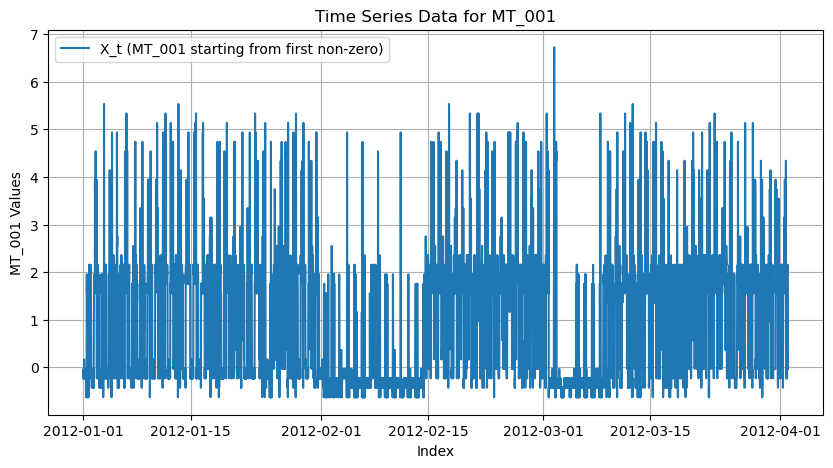

In [5]:
import matplotlib.pyplot as plt

start_date = '2012-01-01'
end_date = '2012-04-01'

plt.figure(figsize=(10, 5))
plt.plot(X_t.loc[start_date:end_date], label='X_t (MT_001 starting from first non-zero)')
#plt.plot(Y_t.index, Y_t.values, label='Y_t (MT_001 > first non-zero index)', linestyle='--')
plt.xlabel('Index')
plt.ylabel('MT_001 Values')
plt.title('Time Series Data for MT_001')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
noise_model = Normal(0.0, 1.0)
hparams = {
    'max_k': 10,
    'samples': 1000,
    'epochs': 100,
    'eta': 1e-2,
    'transform': noise_model,
    'window_size': 1000,
    'K': 10
}

# Train the model using the ts_invariant_statistical_loss function
loader_Xt = DataLoader(X_t.loc[start_date:end_date], batch_size=hparams['samples'], shuffle=False, drop_last=True)
loader_Yt = DataLoader(X_t.loc[start_date:end_date], batch_size=hparams['samples'], shuffle=False, drop_last=True)

losses = []
for i in range(20):
    loss = ts_invariant_statistical_loss_2(model, loader_Xt, loader_Yt, hparams)
    losses.append(loss)

0it [00:00, ?it/s]

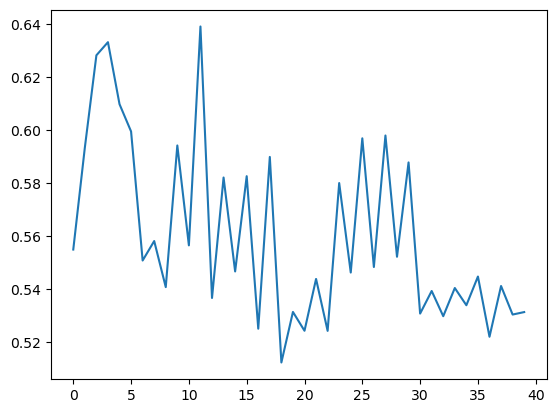

In [ ]:
losses = np.array(losses)
plt.plot(losses.flatten())

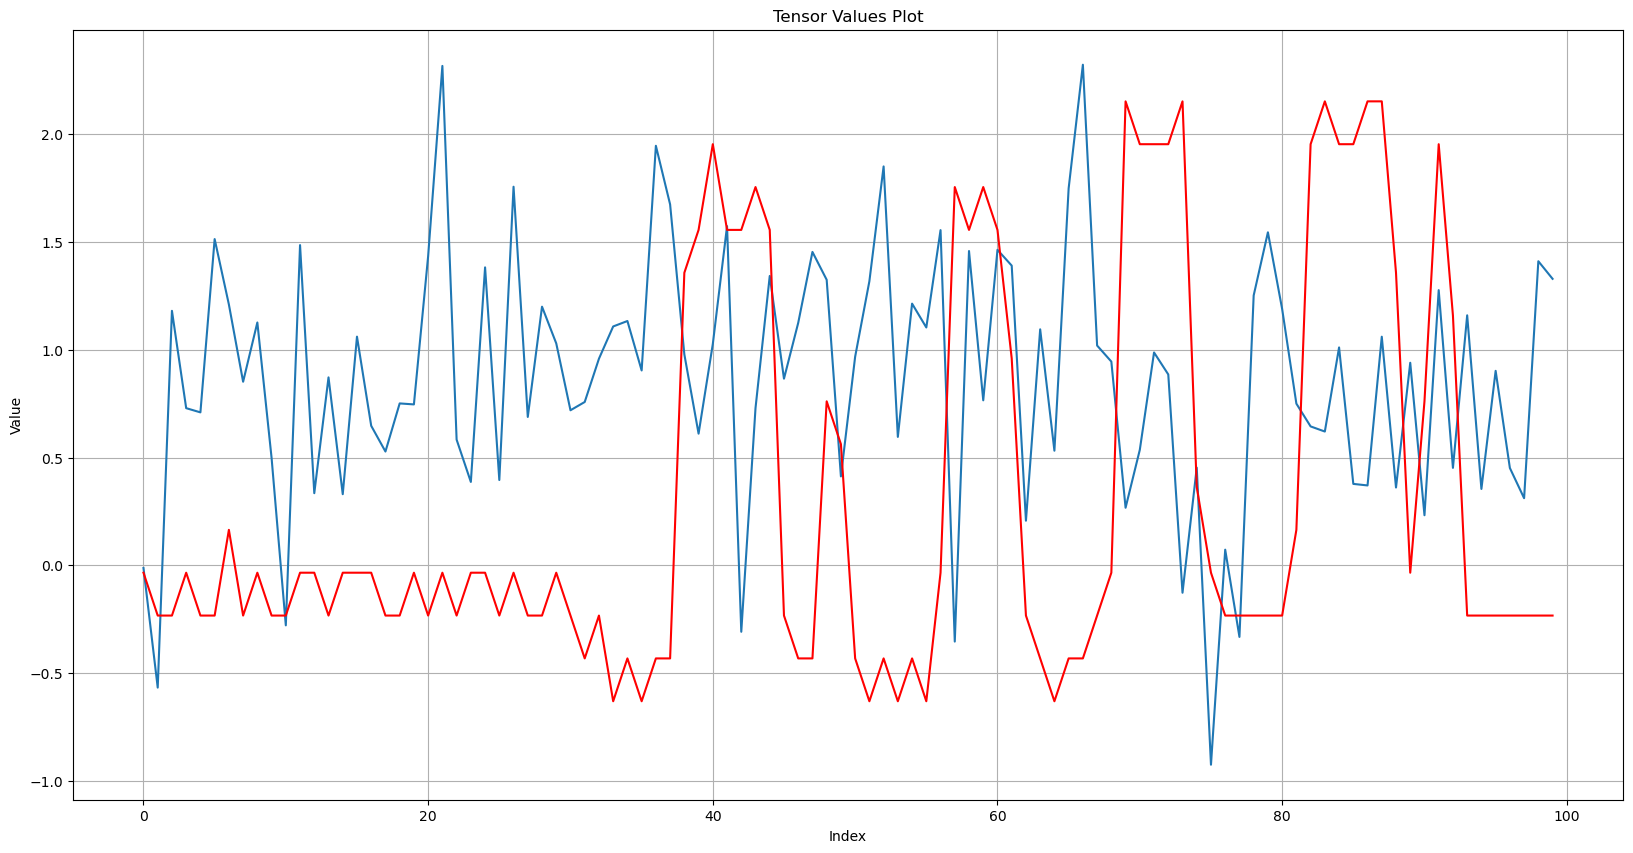

In [ ]:
input_tensor = next(iter(loader_Xt)).unsqueeze(1).unsqueeze(-1).float()
y_k = generated_fictitious(model, input_tensor, hparams['K'])
generated_data = [torch.mean(y_k[i:i+hparams['K']]).item() for i in range(0, len(y_k), hparams['K'])][0:100]

# Convert tensors to a list of floats
data = [t for t in Y_t]
mean = np.mean(data, axis=0)
std = np.std(data, axis=0)
normalized_data = (data - mean) / std

# Plot the data
plt.figure(figsize=(20, 10))
plt.plot(generated_data)
plt.plot(normalized_data[0:100], color='red')
plt.title('Tensor Values Plot')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()